In [20]:
# Heart Disease Classification
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [30]:
# Import data downloaded from Kaggle
df = pd.read_csv("Heart_disease_cleveland_new.csv")

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [32]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [33]:
df.shape

(303, 14)

In [35]:
# Set target to binary
df["target"] = (df["target"] > 0).astype(int)

In [36]:
# Check for missing values
print(df.isna().sum)

<bound method DataFrame.sum of        age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
0    False  False  False     False  False  False    False    False  False   
1    False  False  False     False  False  False    False    False  False   
2    False  False  False     False  False  False    False    False  False   
3    False  False  False     False  False  False    False    False  False   
4    False  False  False     False  False  False    False    False  False   
..     ...    ...    ...       ...    ...    ...      ...      ...    ...   
298  False  False  False     False  False  False    False    False  False   
299  False  False  False     False  False  False    False    False  False   
300  False  False  False     False  False  False    False    False  False   
301  False  False  False     False  False  False    False    False  False   
302  False  False  False     False  False  False    False    False  False   

     oldpeak  slope     ca   thal  target  


In [37]:
# Train/test/split
# Drop target column (y) from the dataset so the model can learn mapping input variables to the outputs.
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression:
  Accuracy = 0.869
  ROC AUC  = 0.953

Decision Tree:
  Accuracy = 0.787
  ROC AUC  = 0.805

Random Forest:
  Accuracy = 0.902
  ROC AUC  = 0.956

Gradient Boosting:
  Accuracy = 0.869
  ROC AUC  = 0.948

Neural Network:
  Accuracy = 0.787
  ROC AUC  = 0.932



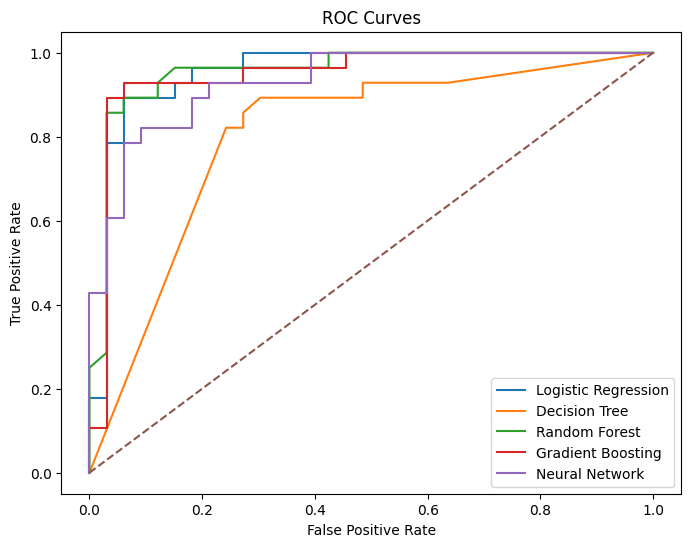

In [38]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

# Neural Network
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=1000,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt.fit(X_train, y_train)

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

# Evaluation test on an unbiased dataset + accuracy and ROC-AUC
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "Random Forest": (rf, X_test),
    "Gradient Boosting": (gb, X_test),
    "Neural Network": (mlp, X_test_scaled)
}

for name, (model, X_evaluation) in models.items():
    y_prediction = model.predict(X_evaluation)
    y_probability = model.predict_proba(X_evaluation)[:, 1]

    acc = accuracy_score(y_test, y_prediction)
    auc = roc_auc_score(y_test, y_probability)

    print(f"{name}:")
    print(f"  Accuracy = {acc:.3f}")
    print(f"  ROC AUC  = {auc:.3f}\n")

# ROC curves
plt.figure(figsize=(8, 6))

for name, (model, X_eval) in models.items():
    y_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

# Visualization of ROC curves
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [19]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

for name, (model, X_evaluation) in models.items():
    y_prediction = model.predict(X_evaluation)

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_prediction))
    print("\nClassification Report:")
    print(classification_report(y_test, y_prediction))


Logistic Regression
Confusion Matrix:
[[28  4]
 [ 6 22]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85        32
         1.0       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


Decision Tree
Confusion Matrix:
[[27  5]
 [13 15]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.84      0.75        32
         1.0       0.75      0.54      0.62        28

    accuracy                           0.70        60
   macro avg       0.71      0.69      0.69        60
weighted avg       0.71      0.70      0.69        60


Random Forest
Confusion Matrix:
[[29  3]
 [ 5 23]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88        32
   

In [35]:
# In this case, Random Forest is the best model as it has a higher accuracy and cross-validated ROC-AUC.

# Let's tune the threshold using Younden Index to reduce the number of false negatives at the cost of 
# increased false positives which is appropriate in this medical screening context.

from sklearn.metrics import roc_curve, confusion_matrix, classification_report
import numpy as np

def youden_threshold(model, X, y):
    y_probability = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_probability)
    return thresholds[np.argmax(tpr - fpr)]

t_rf = youden_threshold(rf, X_test, y_test)

y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= t_rf).astype(int)

print("Threshold:", t_rf)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Threshold: 0.405
Confusion Matrix:
[[27  5]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.84      0.87        32
         1.0       0.83      0.89      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60

